<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Dailychallenge_J5_W5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Préparation des données
Nous chargeons les données IMDB et les transformons en vecteurs binaires (one-hot encoding) pour qu'elles puissent être traitées par le réseau de neurones.

In [1]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Paramètre : on garde les 10 000 mots les plus fréquents
num_words = 10000
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=num_words)

# Fonction pour vectoriser les séquences en matrices binaires
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

# Vectorisation des données
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# Conversion des étiquettes en float32
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

# Création d'un ensemble de validation (10 000 premiers échantillons)
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 2. Construction du modèle
Nous créons un réseau de neurones simple avec deux couches intermédiaires `Dense` utilisant l'activation `relu` et une couche de sortie `sigmoid`.

In [2]:
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 3. Entraînement final (Optimisé)
Nous réentraînons le modèle avec 4 époques pour éviter le surapprentissage détecté précédemment.

In [6]:
# Recréation d'un modèle neuf pour repartir de zéro
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Entraînement optimisé sur 4 époques
model.fit(x_train, y_train, epochs=4, batch_size=512)

# Évaluation finale sur le jeu de test
results = model.evaluate(x_test, y_test)
print(f"\nRésultats finaux sur le jeu de test :")
print(f"Perte (Loss) : {results[0]:.4f}")
print(f"Précision (Accuracy) : {results[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8187 - loss: 0.4704
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9021 - loss: 0.2763
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9251 - loss: 0.2151
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9353 - loss: 0.1827
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8872 - loss: 0.2841

Résultats finaux sur le jeu de test :
Perte (Loss) : 0.2841
Précision (Accuracy) : 0.8872


### 4. Analyse des résultats
Affichons les graphiques de perte (loss) et de précision (accuracy) pour vérifier si le modèle fait du surapprentissage (overfitting).

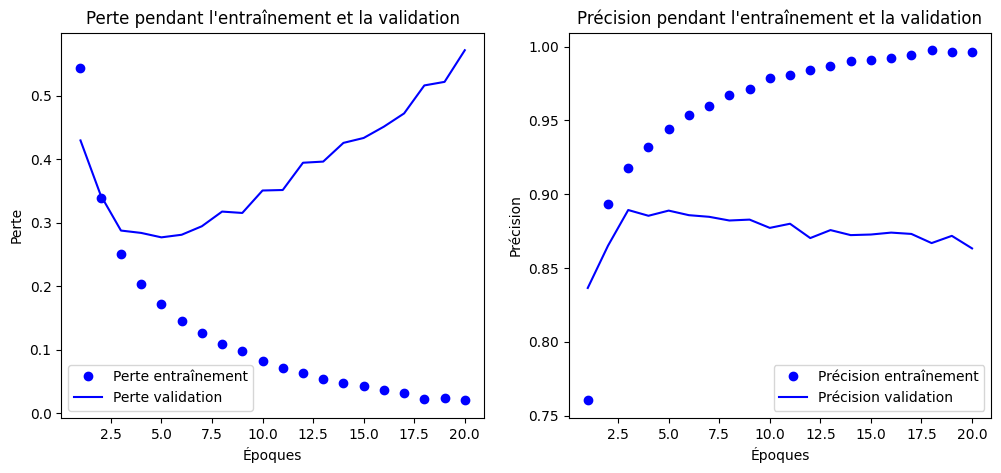

In [4]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

epochs = range(1, len(loss_values) + 1)

# Graphique de la perte
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, 'bo', label='Perte entraînement')
plt.plot(epochs, val_loss_values, 'b', label='Perte validation')
plt.title('Perte pendant l\'entraînement et la validation')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.legend()

# Graphique de la précision
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, 'bo', label='Précision entraînement')
plt.plot(epochs, val_acc, 'b', label='Précision validation')
plt.title('Précision pendant l\'entraînement et la validation')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.legend()

plt.show()

### 5. Évaluation finale
Enfin, nous évaluons le modèle sur les données de test non vues.

In [5]:
results = model.evaluate(x_test, y_test)
print(f"Perte sur le test : {results[0]:.4f}")
print(f"Précision sur le test : {results[1]:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8524 - loss: 0.6244
Perte sur le test : 0.6244
Précision sur le test : 0.8524
